plot_model_performance notebook
- Generates key visualizations to assess FALCON model performance,  namely hold-out test results and learning curves.
- Ensure the <u>Python 3.11 kernel (falcon-env)</u> is selected.
- Run configuration and functions before plotting
- Note: This script requires pre-trained models generated from run_FALCON.py.

In [9]:
### Required Run Parameters ### 

RUN_NAME = "Demo_Results" #Name of folder from which to load the model
cell_type = "RAMOS" #Cell type of model to load 

### Configuration ###

In [10]:
#import statements 
import pickle 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
import pandas as pd

In [11]:
#load the model training pipeline results
model_path = f'../output/{RUN_NAME}/{cell_type}/'
with open(f'{model_path}Pipeline_dict.pkl', 'rb') as file:
    pipeline_results = pickle.load(file)

### Functions ###

In [12]:
def plot_predictions(pipeline, pred = None, exp = None, normalized = True, model_name = None, correlations = True):
    
    ######### Hold Out Validation Pred vs Exp. Plots ########

    if pred is None and exp is None:
        #Get Predictions
        model_name = pipeline['Model_Selection']['Best_Model']['Model_Name']
        data = pipeline['Model_Selection']['Best_Model']['Predictions']

        experimental = data['Experimental_Transfection']
        predicted = data['Predicted_Transfection']
    else:
        experimental = exp
        predicted = pred

    if normalized:
        lower_lim = -0.05
        upper_lim = 1.15
    else:
        upper_lim = 12 #max(predicted.max(), experimental.max())*1.05
        lower_lim = 0 #min(predicted.min(), experimental.min())*1.05

    #Config Plot
    # sns.set_theme(font='Arial', font_scale= 2)
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 12

    #Plot
    fig = plt.figure(figsize=(2.5,2.5), dpi = 200)
    cmap = sns.color_palette("hls", 8, as_cmap=False)

    # color hex code used for ramos is #c8def9
    # color hex code used for thp1 is #FFC080

    reg = sns.regplot(x = experimental, 
                        y = predicted,
                        marker='.',
                        scatter_kws={"color": '#c8def9', "edgecolor": "black",
                                    "alpha": 0.8, "s":200}, 
                        line_kws={"color": "black", "linestyle":'--'})

    #Annotate with correlations
    if correlations:
        pearsons = stats.pearsonr(predicted, experimental)
        spearman = stats.spearmanr(predicted, experimental)

        plt.annotate(r'$r$ = {:.2f}'.format(pearsons[0]), xy=(0.1, 0.9), xycoords='axes fraction',fontsize = '16')
        plt.annotate(r'$\rho$ = {:.2f}'.format(spearman[0]), xy=(0.1, 0.8), xycoords='axes fraction',fontsize = '16')

    #Labels
    plt.ylabel('Predicted Transfection')
    plt.xlabel('Experimental Transfection')

    if normalized:
        reg.set(xlim=(lower_lim, upper_lim), xticks=np.linspace(0,1,5), ylim=(lower_lim, upper_lim), yticks=np.linspace(0,1,5))

    else:
        reg.set(xlim=(lower_lim, upper_lim), xticks=np.linspace(0,20,11), ylim=(lower_lim, upper_lim), yticks=np.linspace(0,20,11))
    plt.xlim(lower_lim, upper_lim)
    plt.ylim(lower_lim, upper_lim)

    #Ticks
    reg.tick_params(colors='black', which='both')
    reg.tick_params(bottom=True, left=True)
    reg.axes.yaxis.label.set_color('black')
    reg.axes.xaxis.label.set_color('black')
    # reg.set_title("Hold-out Set Performance",weight="bold", fontsize = 15)

    reg.set_yticklabels(reg.get_yticklabels())
    reg.set_xticklabels(reg.get_xticklabels())
    # plt.tick_params(axis='both', which='major', labelsize=10)

    reg.spines['left'].set_color('black')
    reg.spines['bottom'].set_color('black')
    reg.spines['right'].set_visible(False)
    reg.spines['top'].set_visible(False)

    plt.grid(False)
    
def plot_learning_curve(pipeline):
    #Extract Results
    cell = pipeline['Cell']
    model_name = pipeline['Model_Selection']['Best_Model']['Model_Name']

    mean_train_scores = pipeline['Learning_Curve']['Train_Error']
    mean_validation_scores = pipeline['Learning_Curve']['Valid_Error']
    train_valid_scores = pd.concat([mean_validation_scores, mean_train_scores], 
                                   ignore_index= True)

    # Plot configurations
    plt.rcParams.update({
        'font.family': 'Arial',
        'font.size': 12})

    fig, ax = plt.subplots(figsize = (2.5, 1.5), dpi = 200)

    line = sns.lineplot(data =  train_valid_scores,
                            x = "Train_size", 
                            y = 'Percent_Error', 
                            hue = "Score_Type", 
                            errorbar = "sd", 
                            linewidth = 3, 
                            palette=sns.color_palette("Set2" , 2))

    #line.set(xlim=(0, 540), xticks=np.linspace(0,540,6), ylim=(0, 20), yticks=np.arange(0,25,5))
    line.tick_params(colors='black', which='both')  # 'both' refers to minor and major axes
    
    # add tick marks on x-axis or y-axis
    line.tick_params(bottom=True, left=True)
    
    # x-axis and y-axis label color
    line.axes.yaxis.label.set_color('black')
    line.axes.xaxis.label.set_color('black')

    #line.set_yticklabels(line.get_yticklabels())
    #line.set_xticklabels(line.get_xticklabels())

    line.spines['left'].set_color('black')
    line.spines['bottom'].set_color('black')        # x-axis and y-axis spines
    line.spines['right'].set_visible(False)
    line.spines['top'].set_visible(False)

    line.tick_params(colors='black', which='both')  # 'both' refers to minor and major axes

    plt.grid(visible = False)
    plt.xlabel('Training size')
    plt.ylabel('Percent Error')
    plt.legend(fontsize = 'small', loc='upper right', framealpha = 0)

### Plotting ###


########## MODEL SELECTION PLOTTING


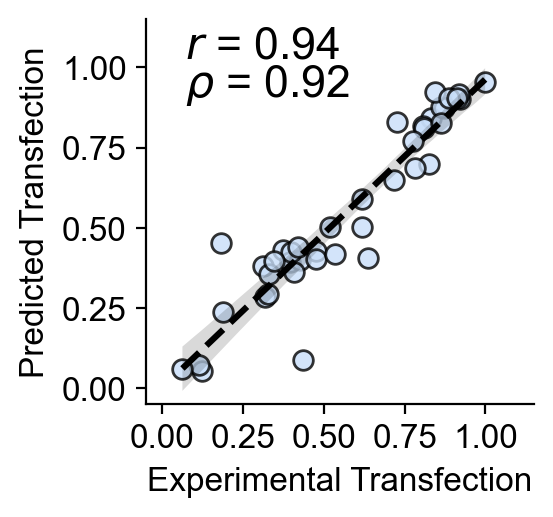

In [13]:
print('\n########## MODEL SELECTION PLOTTING')
plot_predictions(pipeline_results)

#example save statement
plt.savefig(model_path + f'XGB_{cell_type}_predictions.svg', dpi=600, format = 'svg',transparent=True, bbox_inches = 'tight')


########## LEARNING CURVE PLOTTING


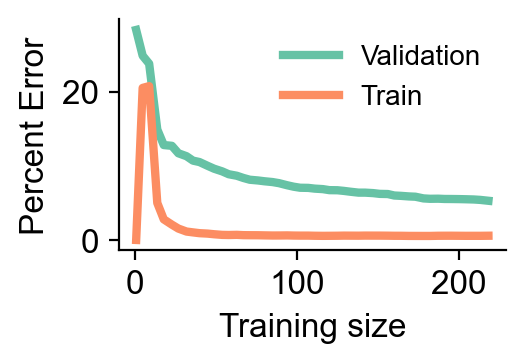

In [14]:
print('\n########## LEARNING CURVE PLOTTING')
plot_learning_curve(pipeline_results)

#example save statement
plt.savefig(model_path + f'XGB_{cell_type}_learning_curve.svg', dpi=600, format = 'svg',transparent=True, bbox_inches = 'tight')